# Sales Analysis

## Import libraries

In [1]:
import pandas as pd

import matplotlib.pyplot as plt

import os

## Merge multiples .CSV files

In [2]:
path = './Datasets'

files = [file for file in os.listdir(path) if not file.startswith('.')] # Ignore hidden files

all_sales_data = pd.DataFrame()

for file in files:
    current_data = pd.read_csv(path+"/"+file)
    all_sales_data = pd.concat([all_sales_data, current_data])
    
all_sales_data.to_csv("all_sales_data.csv", index=False)

## Load the merged file

In [3]:
df = pd.read_csv('all_sales_data.csv')

## Data Cleaning 

### Check dimensions 

In [4]:
df.shape

(186850, 6)

In [5]:
df.sample(10)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
53821,318046,USB-C Charging Cable,1,11.95,12/17/19 15:47,"294 11th St, Seattle, WA 98101"
123119,196588,ThinkPad Laptop,1,999.99,05/26/19 09:14,"875 Dogwood St, Boston, MA 02215"
85164,230454,Apple Airpods Headphones,1,150,07/18/19 15:09,"491 South St, San Francisco, CA 94016"
122951,196428,USB-C Charging Cable,1,11.95,05/24/19 16:06,"318 Highland St, New York City, NY 10001"
158179,262593,iPhone,1,700,10/14/19 07:51,"284 8th St, New York City, NY 10001"
116730,172960,Lightning Charging Cable,2,14.95,03/03/19 12:25,"612 Cherry St, Los Angeles, CA 90001"
70821,144345,Bose SoundSport Headphones,1,99.99,01/22/19 14:50,"740 4th St, Atlanta, GA 30301"
5702,182011,Apple Airpods Headphones,1,150,04/12/19 19:48,"92 8th St, Atlanta, GA 30301"
31575,296791,Lightning Charging Cable,1,14.95,12/04/19 22:57,"678 14th St, Portland, OR 97035"
73728,147115,Apple Airpods Headphones,1,150,01/05/19 15:17,"254 Jackson St, New York City, NY 10001"


### Check for nulls

In [6]:
df.isnull().any()

Order ID            True
Product             True
Quantity Ordered    True
Price Each          True
Order Date          True
Purchase Address    True
dtype: bool

#### Drop all nulls values

In [7]:
df = df.dropna()

### Check for duplicates

In [8]:
df.duplicated().any()

True

#### Drop duplicates

In [9]:
df = df.drop_duplicates()

## Check data types

In [10]:
df.dtypes

Order ID            object
Product             object
Quantity Ordered    object
Price Each          object
Order Date          object
Purchase Address    object
dtype: object

#### Get rid of the OR in date

In [11]:
df = df[df['Order Date'].str[0:2]!='Or']

#### Change to Numeric

In [12]:
df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'])
df['Price Each'] = pd.to_numeric(df['Price Each'])

#### Change to Datetime

In [13]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [14]:
df.dtypes

Order ID                    object
Product                     object
Quantity Ordered             int64
Price Each                 float64
Order Date          datetime64[ns]
Purchase Address            object
dtype: object

## Question 1: What was the best month for sales? How much was earned that month?

### Add a Column for Month

In [18]:
df['Month'] = pd.to_datetime(df['Order Date']).dt.month

In [19]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4


### Add a Column for Sales

In [20]:
df['Sales'] = df['Quantity Ordered'].astype('int') * df['Price Each'].astype('float')

In [21]:
df.sample(10)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales
100340,218217,AA Batteries (4-pack),2,3.84,2019-06-13 20:54:00,"989 Park St, Boston, MA 02215",6,7.68
25397,243387,iPhone,1,700.00,2019-08-07 22:20:00,"854 Chestnut St, Los Angeles, CA 90001",8,700.00
150730,291798,Wired Headphones,1,11.99,2019-11-18 16:30:00,"545 Highland St, Austin, TX 73301",11,11.99
46110,310682,iPhone,1,700.00,2019-12-16 12:14:00,"290 Meadow St, Atlanta, GA 30301",12,700.00
22906,241012,Lightning Charging Cable,1,14.95,2019-08-18 18:14:00,"772 10th St, Seattle, WA 98101",8,14.95
108154,164757,USB-C Charging Cable,1,11.95,2019-03-02 19:32:00,"437 West St, Dallas, TX 75001",3,11.95
110237,166749,Bose SoundSport Headphones,1,99.99,2019-03-08 18:33:00,"330 Lakeview St, Boston, MA 02215",3,99.99
177782,250662,Apple Airpods Headphones,1,150.00,2019-09-28 11:42:00,"869 12th St, San Francisco, CA 94016",9,150.00
25812,243781,Apple Airpods Headphones,1,150.00,2019-08-25 13:29:00,"588 4th St, Los Angeles, CA 90001",8,150.00
86150,231394,Lightning Charging Cable,1,14.95,2019-07-26 23:33:00,"967 Ridge St, Atlanta, GA 30301",7,14.95


In [22]:
max_sales_month = df.groupby(['Month']).sum()
max_sales_month

,Quantity Ordered,Price Each,Sales
Month,,,
1,10893,1810924.81,1821413.16
2,13431,2186940.38,2200078.08
3,16979,2789084.64,2804973.35
4,20536,3366218.76,3389217.98
5,18653,3133134.61,3150616.23
6,15234,2560503.50,2576280.15
7,16054,2631225.12,2646461.32
8,13429,2226963.90,2241083.37
9,13091,2081897.65,2094465.69


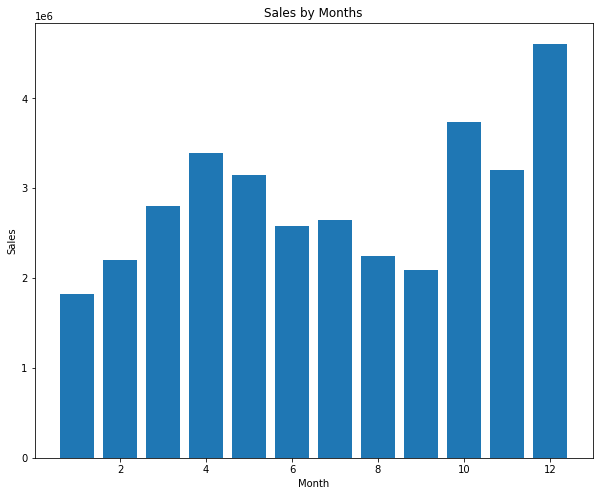

In [23]:
plt.figure(figsize=(10,8))
plt.bar(max_sales_month.index, max_sales_month['Sales'])

plt.title('Sales by Months')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

## Question 2: What city sold the most product?

### Add city column

In [24]:
def get_city(address):
    return address.split(",")[1].strip(" ")

def get_state(address):
    return address.split(",")[2].split(" ")[1]

df['City'] = df['Purchase Address'].apply(lambda x: f"{get_city(x)}  ({get_state(x)})")
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,23.90,Dallas (TX)
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,99.99,Boston (MA)
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles (CA)
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles (CA)
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,11.99,Los Angeles (CA)


In [25]:
max_sales_city = df.groupby(['City']).sum()
max_sales_city

,Quantity Ordered,Price Each,Month,Sales
City,,,,
Atlanta (GA),16584,2778608.69,104649,2794199.07
Austin (TX),11137,1808340.03,69720,1818044.33
Boston (MA),22494,3634398.40,140898,3658627.65
Dallas (TX),16707,2750026.38,104447,2765373.96
Los Angeles (CA),33247,5417171.70,208020,5448304.28
New York City (NY),27903,4632920.54,175557,4661867.14
Portland (ME),2746,446752.36,17119,449321.38
Portland (OR),11291,1859836.44,70517,1870010.56
San Francisco (CA),50169,8204001.38,314949,8254743.55


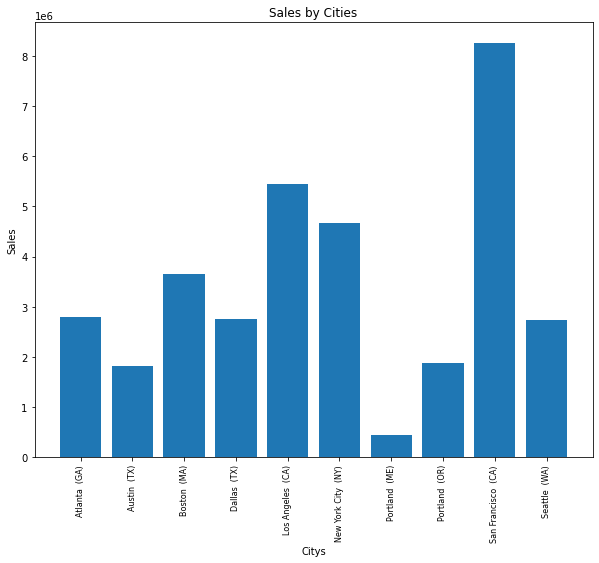

In [26]:
plt.figure(figsize=(10,8))

plt.bar(max_sales_city.index, max_sales_city['Sales'])

plt.title('Sales by Cities')
plt.xlabel('Citys')
plt.ylabel('Sales')
plt.xticks(rotation='vertical', size=8)
plt.show()

## Question 3: Sales By Hour?

### Add hour column

In [27]:
df['Hour'] = pd.to_datetime(df['Order Date']).dt.hour

In [28]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,23.90,Dallas (TX),8
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,99.99,Boston (MA),22
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles (CA),14
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles (CA),14
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,11.99,Los Angeles (CA),9


In [29]:
max_sales_hour = df.groupby(['Hour']).sum()
max_sales_hour

,Quantity Ordered,Price Each,Month,Sales
Hour,,,,
0,4420,709124.09,27477,713548.66
1,2616,458187.02,16643,460563.90
2,1397,233821.65,8502,234839.45
3,927,144711.47,5903,145742.94
4,935,161943.24,6135,162546.07
5,1492,229606.26,9298,230664.87
6,2809,444850.12,17528,447963.01
7,4547,739781.31,28787,744067.32
8,6998,1185930.85,43605,1192309.20


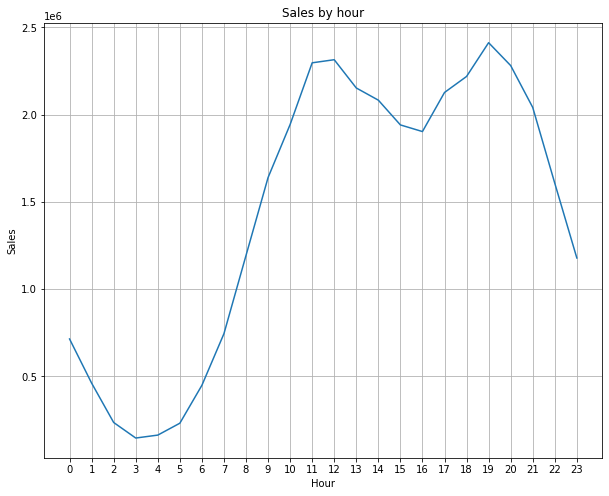

In [38]:
plt.figure(figsize=(10,8))

plt.plot(max_sales_hour.index, max_sales_hour['Sales'])

plt.title('Sales by hour')
plt.xlabel('Hour')
plt.ylabel('Sales')
plt.xticks(max_sales_hour.index)
plt.grid()
plt.show()

## Question 4: What products sold the most?

In [31]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,23.90,Dallas (TX),8
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,99.99,Boston (MA),22
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles (CA),14
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles (CA),14
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,11.99,Los Angeles (CA),9


In [32]:
most_sold = df.groupby(['Product']).sum()
most_sold

,Quantity Ordered,Price Each,Month,Sales,Hour
Product,,,,,
20in Monitor,4126,450739.02,29319,453818.74,58729
27in 4K Gaming Monitor,6239,2427687.75,44396,2433147.61,90841
27in FHD Monitor,7541,1124625.02,52484,1131074.59,107422
34in Ultrawide Monitor,6192,2346058.26,43258,2352898.08,88957
AA Batteries (4-pack),27615,78942.72,145423,106041.60,298077
AAA Batteries (4-pack),30986,61629.88,146149,92648.14,296904
Apple Airpods Headphones,15637,2328750.00,109304,2345550.00,222938
Bose SoundSport Headphones,13430,1329667.02,93918,1342865.70,192077
Flatscreen TV,4813,1438200.00,34172,1443900.00,68719


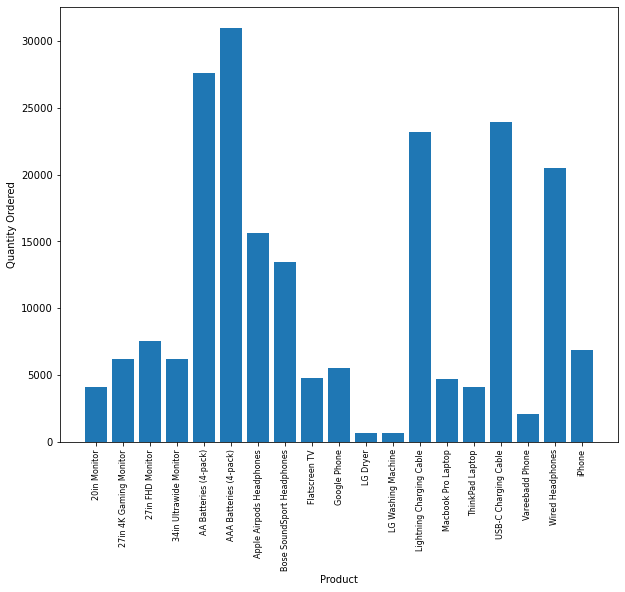

In [33]:
plt.figure(figsize=(10,8))

plt.bar(most_sold.index, most_sold['Quantity Ordered'])

plt.xlabel('Product')
plt.ylabel('Quantity Ordered')
plt.xticks(rotation='vertical', size=8)
plt.show()

## Question 5: What products are most often sold together?

In [34]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,23.90,Dallas (TX),8
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,99.99,Boston (MA),22
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles (CA),14
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles (CA),14
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,11.99,Los Angeles (CA),9


In [35]:
# https://stackoverflow.com/questions/43348194/pandas-select-rows-if-id-appear-several-time
same_order_id = df[df['Order ID'].duplicated(keep=False)]
same_order_id

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles (CA),14
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles (CA),14
18,176574,Google Phone,1,600.00,2019-04-03 19:42:00,"20 Hill St, Los Angeles, CA 90001",4,600.00,Los Angeles (CA),19
19,176574,USB-C Charging Cable,1,11.95,2019-04-03 19:42:00,"20 Hill St, Los Angeles, CA 90001",4,11.95,Los Angeles (CA),19
32,176586,AAA Batteries (4-pack),2,2.99,2019-04-10 17:00:00,"365 Center St, San Francisco, CA 94016",4,5.98,San Francisco (CA),17
...,...,...,...,...,...,...,...,...,...,...
186792,259303,AA Batteries (4-pack),1,3.84,2019-09-20 20:18:00,"106 7th St, Atlanta, GA 30301",9,3.84,Atlanta (GA),20
186803,259314,Wired Headphones,1,11.99,2019-09-16 00:25:00,"241 Highland St, Atlanta, GA 30301",9,11.99,Atlanta (GA),0
186804,259314,AAA Batteries (4-pack),2,2.99,2019-09-16 00:25:00,"241 Highland St, Atlanta, GA 30301",9,5.98,Atlanta (GA),0
186841,259350,Google Phone,1,600.00,2019-09-30 13:49:00,"519 Maple St, San Francisco, CA 94016",9,600.00,San Francisco (CA),13


In [36]:
# Referenced: https://stackoverflow.com/questions/27298178/concatenate-strings-from-several-rows-using-pandas-groupby
df['Grouped'] = df.groupby('Order ID')['Product'].transform(lambda x: ','.join(x))
df2 = df[['Order ID', 'Grouped']].drop_duplicates()

In [37]:
# Referenced: https://stackoverflow.com/questions/52195887/counting-unique-pairs-of-numbers-into-a-python-dictionary
from itertools import combinations
from collections import Counter

count = Counter()

for row in df2['Grouped']:
    row_list = row.split(',')
    count.update(Counter(combinations(row_list, 2)))

for key,value in count.most_common(10):
    print(key, value)

('iPhone', 'Lightning Charging Cable') 1002
('Google Phone', 'USB-C Charging Cable') 985
('iPhone', 'Wired Headphones') 447
('Google Phone', 'Wired Headphones') 413
('Vareebadd Phone', 'USB-C Charging Cable') 361
('iPhone', 'Apple Airpods Headphones') 360
('Google Phone', 'Bose SoundSport Headphones') 220
('USB-C Charging Cable', 'Wired Headphones') 159
('Vareebadd Phone', 'Wired Headphones') 143
('Lightning Charging Cable', 'Wired Headphones') 92
